## PARROTS WORKSHOP ##

## Step 7. Setup check

In [1]:
from pathlib import Path
import yaml
import sys
import pandas as pd

# Find workshop folder
WORKSHOP_DIR = Path.cwd().resolve()

if WORKSHOP_DIR.name.lower() == "notebooks":
    WORKSHOP_DIR = WORKSHOP_DIR.parent

EXAMPLE_DIR = WORKSHOP_DIR / "Example"
print("Example directory:", EXAMPLE_DIR)

# Load main config
CONFIG_PATH = EXAMPLE_DIR / "config.yaml"

assert CONFIG_PATH.exists(), f"Config file not found: {CONFIG_PATH}"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# Helper: make relative paths start from Example/
def fix_path(p):
    p = Path(p).expanduser()
    return p if p.is_absolute() else EXAMPLE_DIR / p

# Load environment config
ENV_CONFIG_PATH = fix_path(config["environment"]).resolve()

with open(ENV_CONFIG_PATH) as f:
    env_file = yaml.safe_load(f)

env_config = env_file["environment"]

# Read paths
PARROTS_DIR = Path(env_config["parrots_dir"]).expanduser().resolve()
BASE_DIR = fix_path(config["input_options"]["base_dir"]).resolve()
INPUT_PDB = fix_path(config["input_options"]["input_pdb"]).resolve()
TEMPLATE_FASTA = fix_path(config["input_options"]["template_fasta"]).resolve()
BINDER_CHAIN = config["input_options"]["binder_chain"]

# Print paths
print("Workshop directory:", WORKSHOP_DIR)
print("Example directory:", EXAMPLE_DIR)
print("Config path:", CONFIG_PATH)
print("Environment config:", ENV_CONFIG_PATH)
print("PARROTS directory:", PARROTS_DIR)
print("Base directory:", BASE_DIR)
print("Input PDB:", INPUT_PDB)
print("Template FASTA:", TEMPLATE_FASTA)
print("Binder chain:", BINDER_CHAIN)

# Check paths
assert CONFIG_PATH.exists(), "Config file not found"
assert ENV_CONFIG_PATH.exists(), "Environment config file not found"
assert PARROTS_DIR.exists(), "PARROTS directory not found"
assert BASE_DIR.exists(), "base_dir not found"
assert INPUT_PDB.exists(), "input_pdb not found"
assert TEMPLATE_FASTA.exists(), "template_fasta not found"

print("\nSetup check passed.")

Example directory: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example
Workshop directory: /ifs/scratch2/home/bs3281/PARROTS_workshop
Example directory: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example
Config path: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example/config.yaml
Environment config: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example/environment.yaml
PARROTS directory: /ifs/scratch2/home/bs3281/PARROTS
Base directory: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example
Input PDB: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example/inputs/PD1_PDBs/4zqk_PD1_rx.pdb
Template FASTA: /ifs/scratch2/home/bs3281/PARROTS_workshop/Example/inputs/4ZQK_pd1_truncated.fasta
Binder chain: A

Setup check passed.


# ITER_1 Design analysis

In [2]:
Design_output_dir = "/ifs/scratch2/home/bs3281/PARROTS_workshop/Test_2/ITER_1/Design_output"

In [3]:
import sys
sys.path.insert(0, str(PARROTS_DIR))

from PARROTS_Analysis.parrots_plots import calculate_design_pass_rates

print(f"Percentage of designs passing thresholds in design step 1 and design step 2")
percent_pass = calculate_design_pass_rates(Design_output_dir)

Percentage of designs passing thresholds in design step 1 and design step 2
[step_1] 6/6 passed (100.00%)
[step_2] 1/12 passed (8.33%)


Analyze metrics of design step 1 vs. step 2 (passing designs)

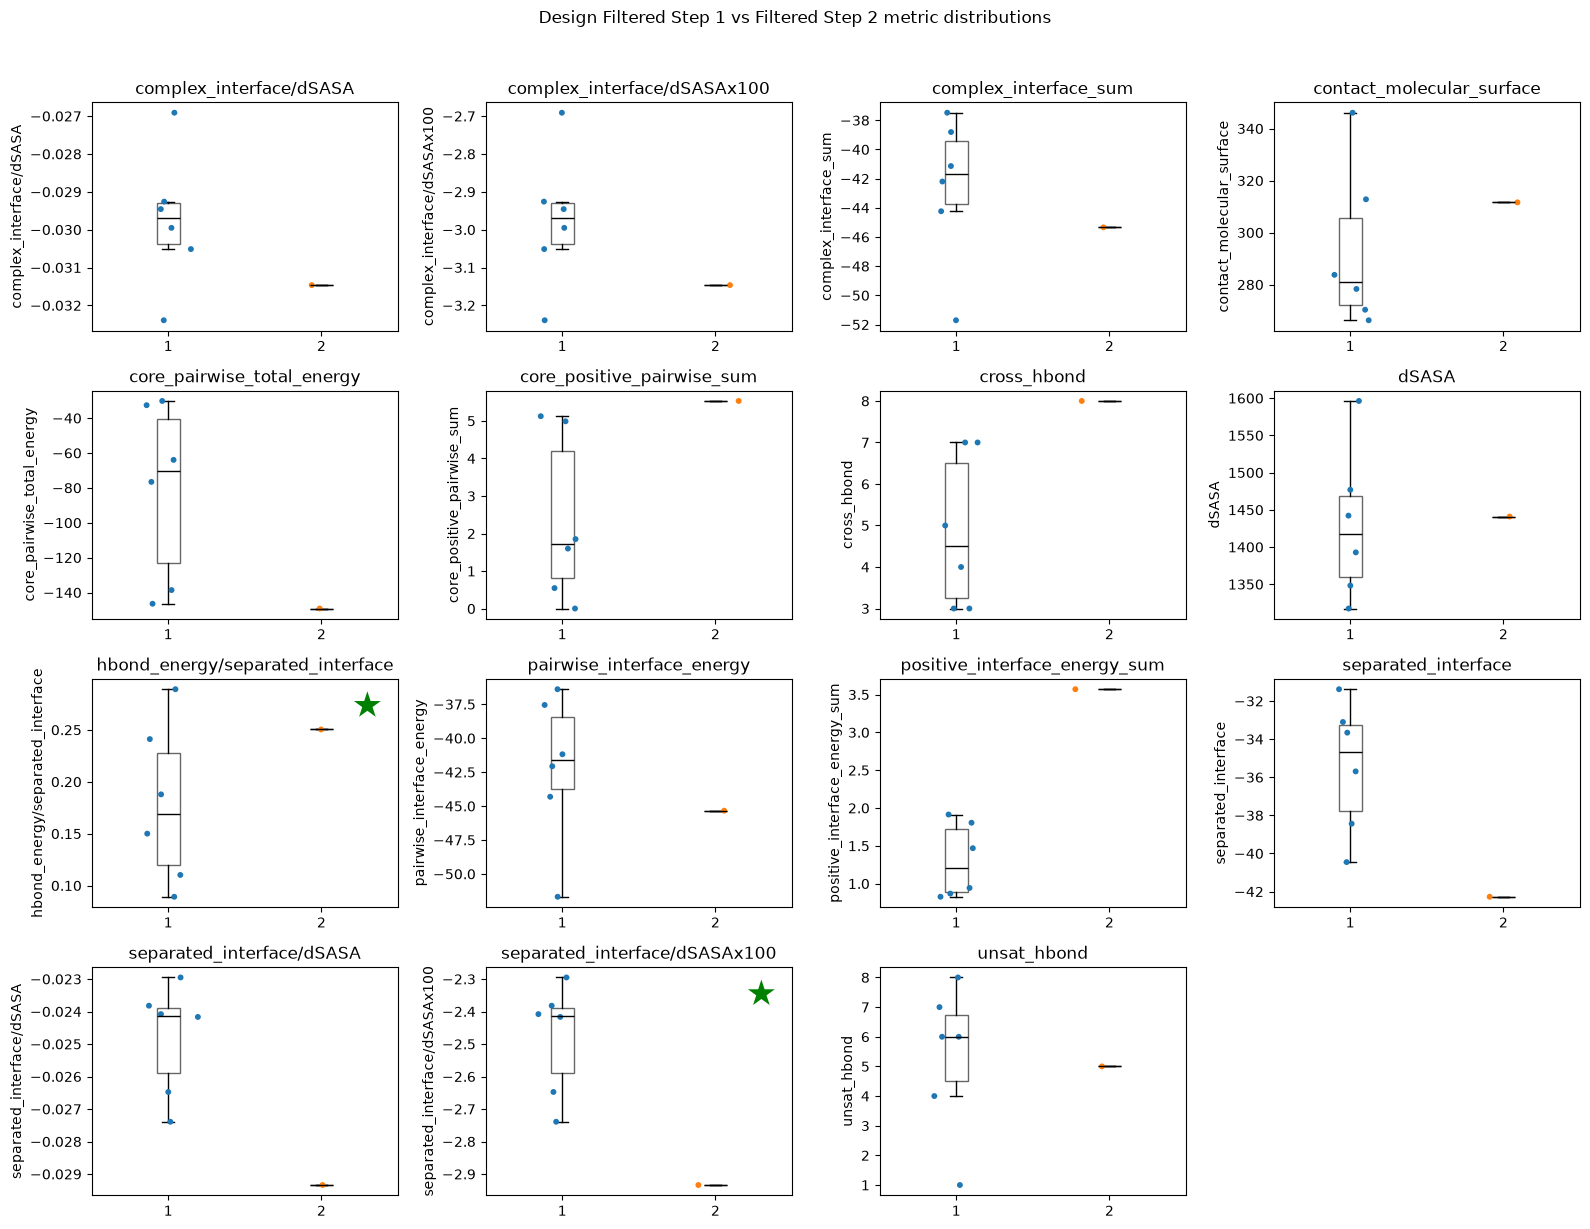

In [4]:
from PARROTS_Analysis.parrots_plots import plot_step1_vs_step2_metric_boxplots

fig, axes = plot_step1_vs_step2_metric_boxplots(Design_output_dir)

# Let's visualize design step 2 metrics relative to thresholds

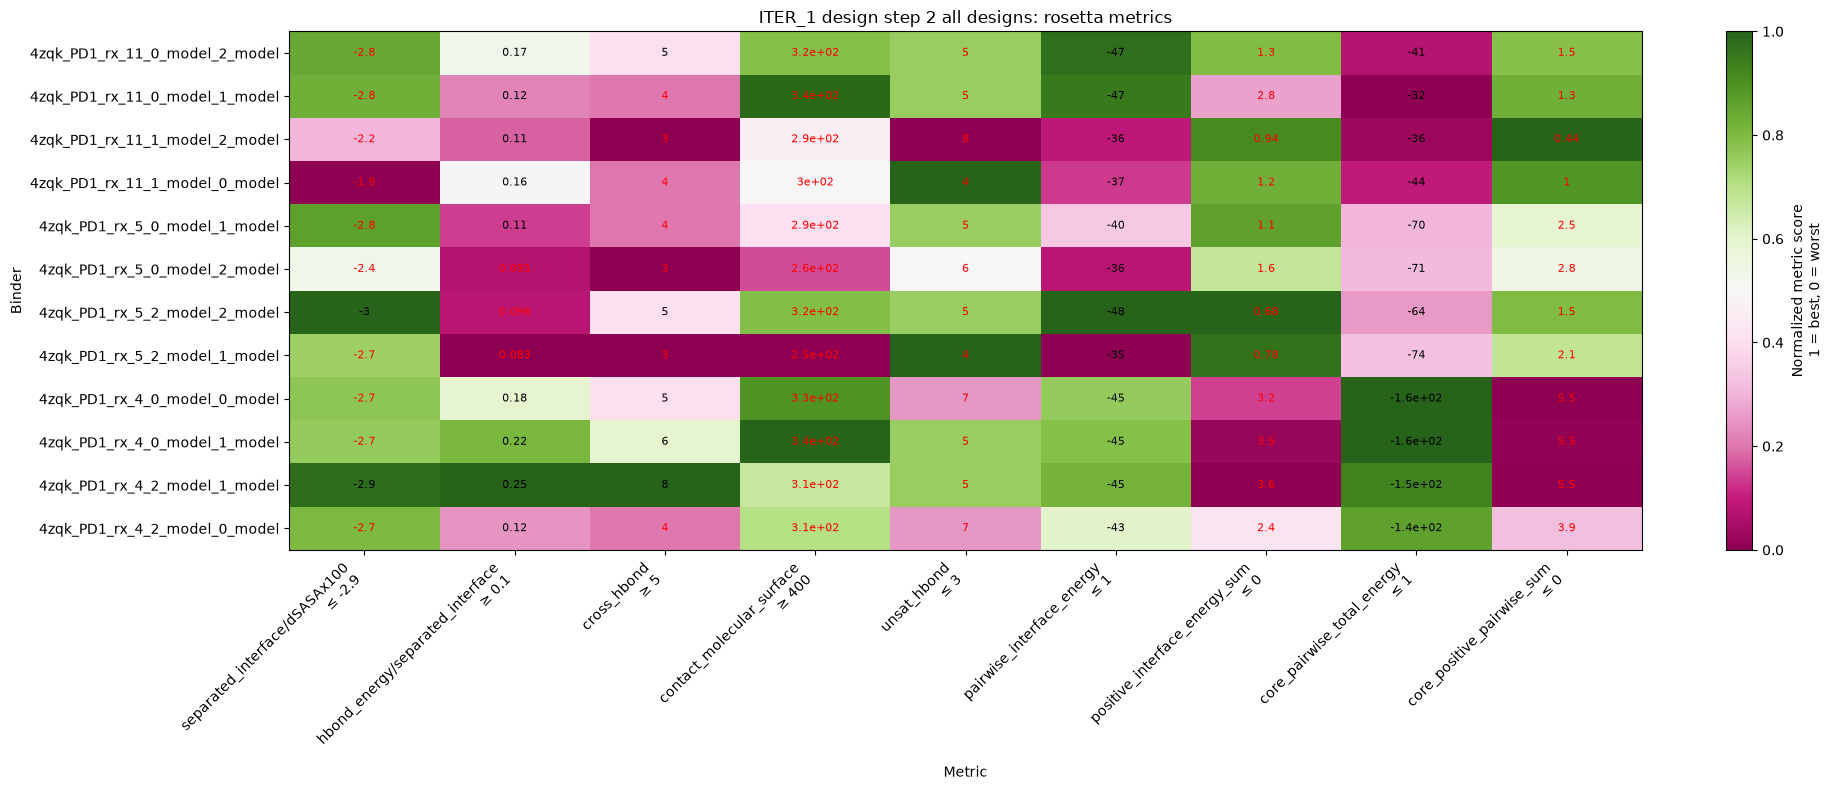

In [5]:
from PARROTS_Analysis.parrots_plots import make_threshold_heatmap

df_step_2_all = pd.read_csv('/ifs/scratch2/home/bs3281/PARROTS_workshop/Test_2/ITER_1/Design_output/step_2_design_metrics.csv')

fig, ax, normalized_df, pass_fail_df = make_threshold_heatmap(
	df_step_2_all,
	metric_group='rosetta',
	title="ITER_1 design step 2 all designs: rosetta metrics",
	figsize=(20,8)
)

In [6]:
from PARROTS_Analysis.parrots_plots import report_structural_threshold_passes

df_af3_all = pd.read_csv('/ifs/scratch2/home/bs3281/PARROTS_workshop/Test_2/ITER_1/Predict_output/AF3_metrics.csv')
passed_structural = report_structural_threshold_passes(df_af3_all)


Structural threshold pass counts:
Total designs: 1
avg_interface_chains_PAE < 10: 0 / 1 pass
avg_per_chain_ipTM > 0.6: 0 / 1 pass
All structural thresholds: 0 / 1 pass


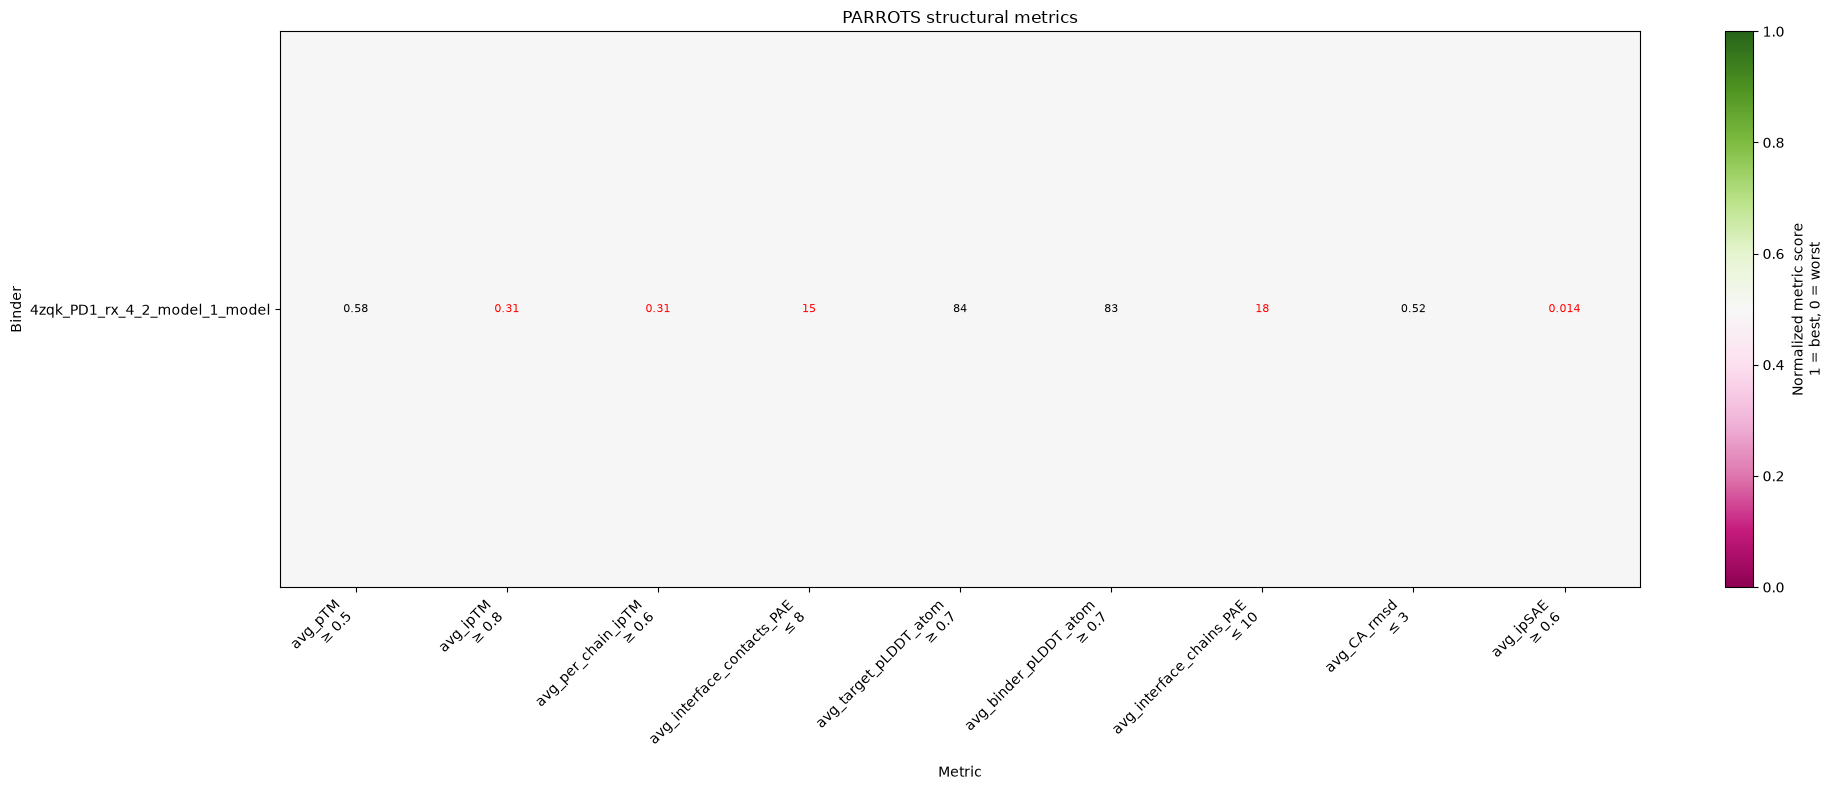

In [9]:
fig, ax, normalized_df, pass_fail_df = make_threshold_heatmap(
	df_af3_all,
	metric_group='af3',
	title="PARROTS structural metrics",
	figsize=(20,8)
)


## Do any of your designs pass all thresholds? 

How can we improve our designs ?

How can we maximize the number of binders that pass design step 2? 

Maximize at RFD step: 
1. Better hotspots
2. More scaffolds
3. How else?

Maximize at design step:
1. What do you think?

*Note: Design must pass both filters to pass step 2:*

	"separated_interface/dSASAx100": {"threshold": -2.9, "direction": "<"},

	"hbond_energy/separated_interface": {"threshold": 0.10, "direction": ">"},

## Definitions of Structural Thresholds

```text
dG_separated = Energy_complex − Energy_separated_complex
```

```text
dSASA =  SASAcomplex - SASAseparated complex
```

**dG_separated/dSASA x 100** 
separated binding energy per unit interface area. Scaling by dSASA controls for large interfaces having more energy. x100 allows non-decimal values.

**hbond_energy/separated_interface:**
amount of interface energy (dG_separated) accounted for by cross interface hydrogen bonds



## ##################################### ##

## ITER_2 Design analysis

In [ ]:
Design_output_2_dir = "/ifs/scratch2/home/bs3281/PARROTS_workshop/TEST_BS/ITER_2/Design_output"

percent_pass = calculate_design_pass_rates(Design_output_dir)
fig, axes = plot_step1_vs_step2_metric_boxplots(Design_output_dir)

In [ ]:
df_step_2_all_iter_2 = ""

fig, ax, normalized_df, pass_fail_df = make_threshold_heatmap(
	df_step_2_all_iter_2,
	metric_group='rosetta',
	title="ITER_2 design step 2 all designs: rosetta metrics",
	figsize=(20,8)
)

## Who made the best binders? ##

Let's look at PD-L1 binder results:

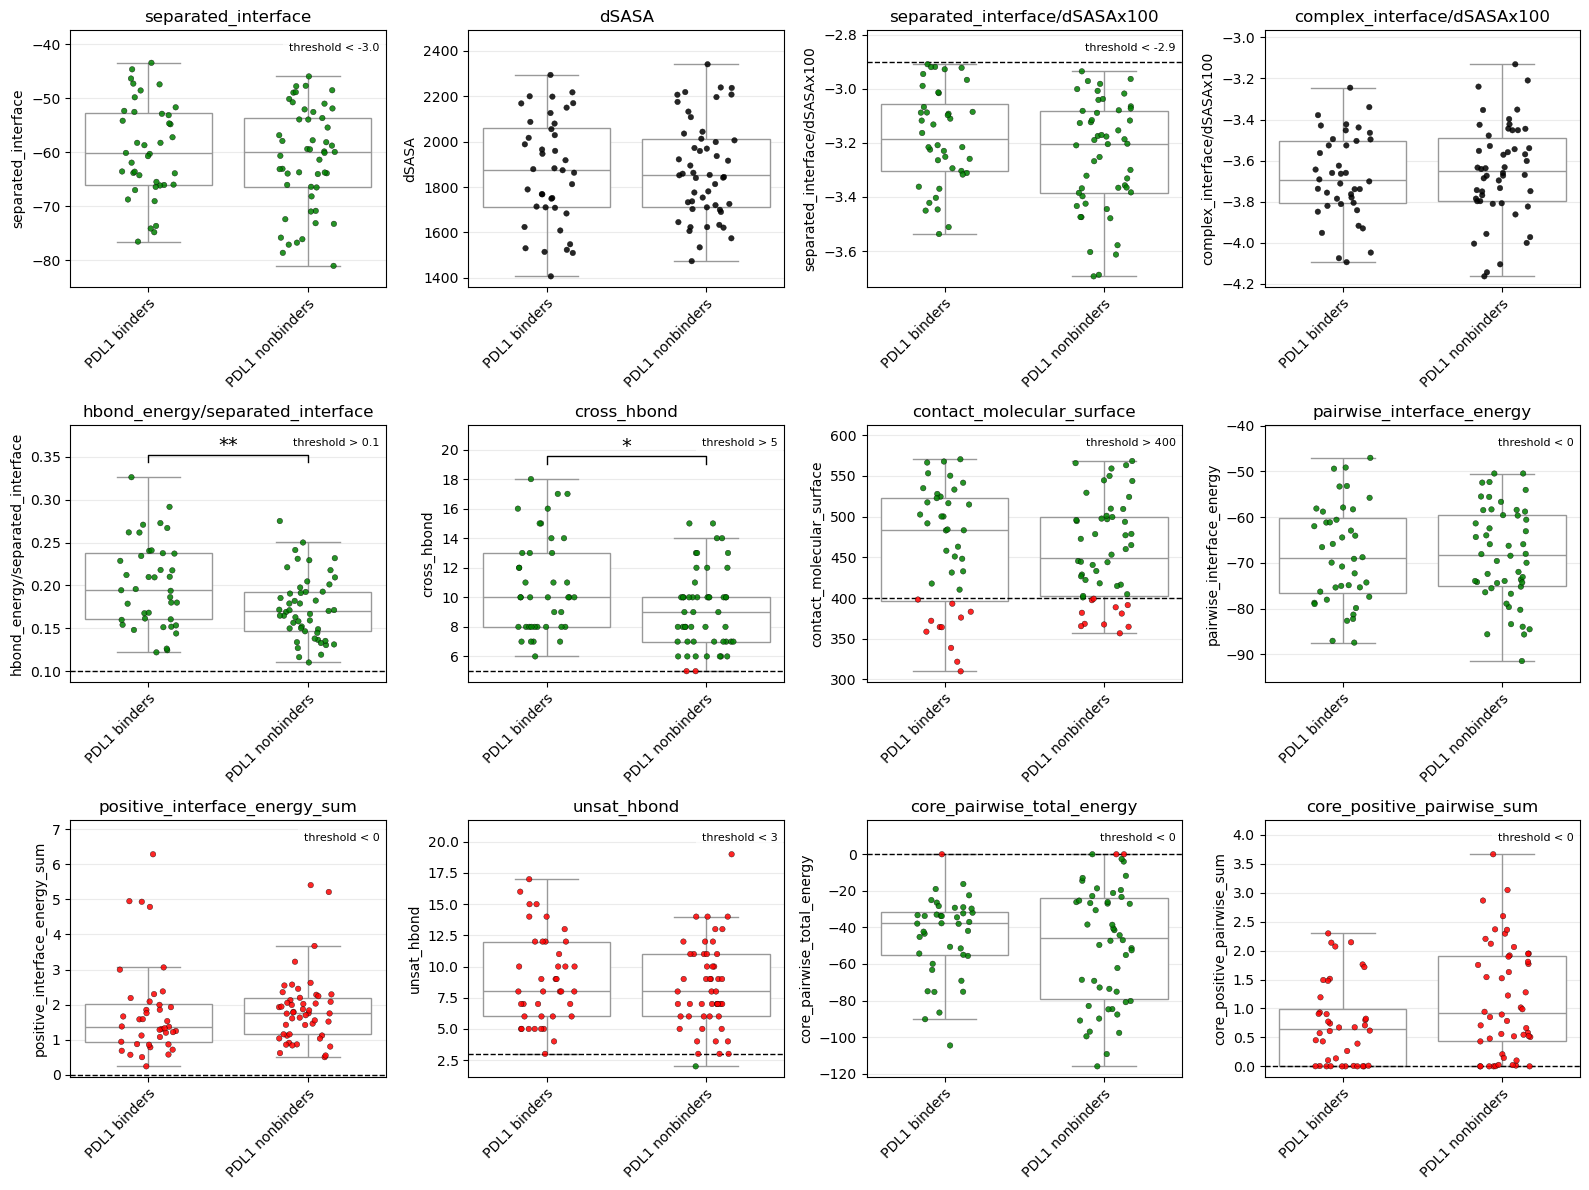

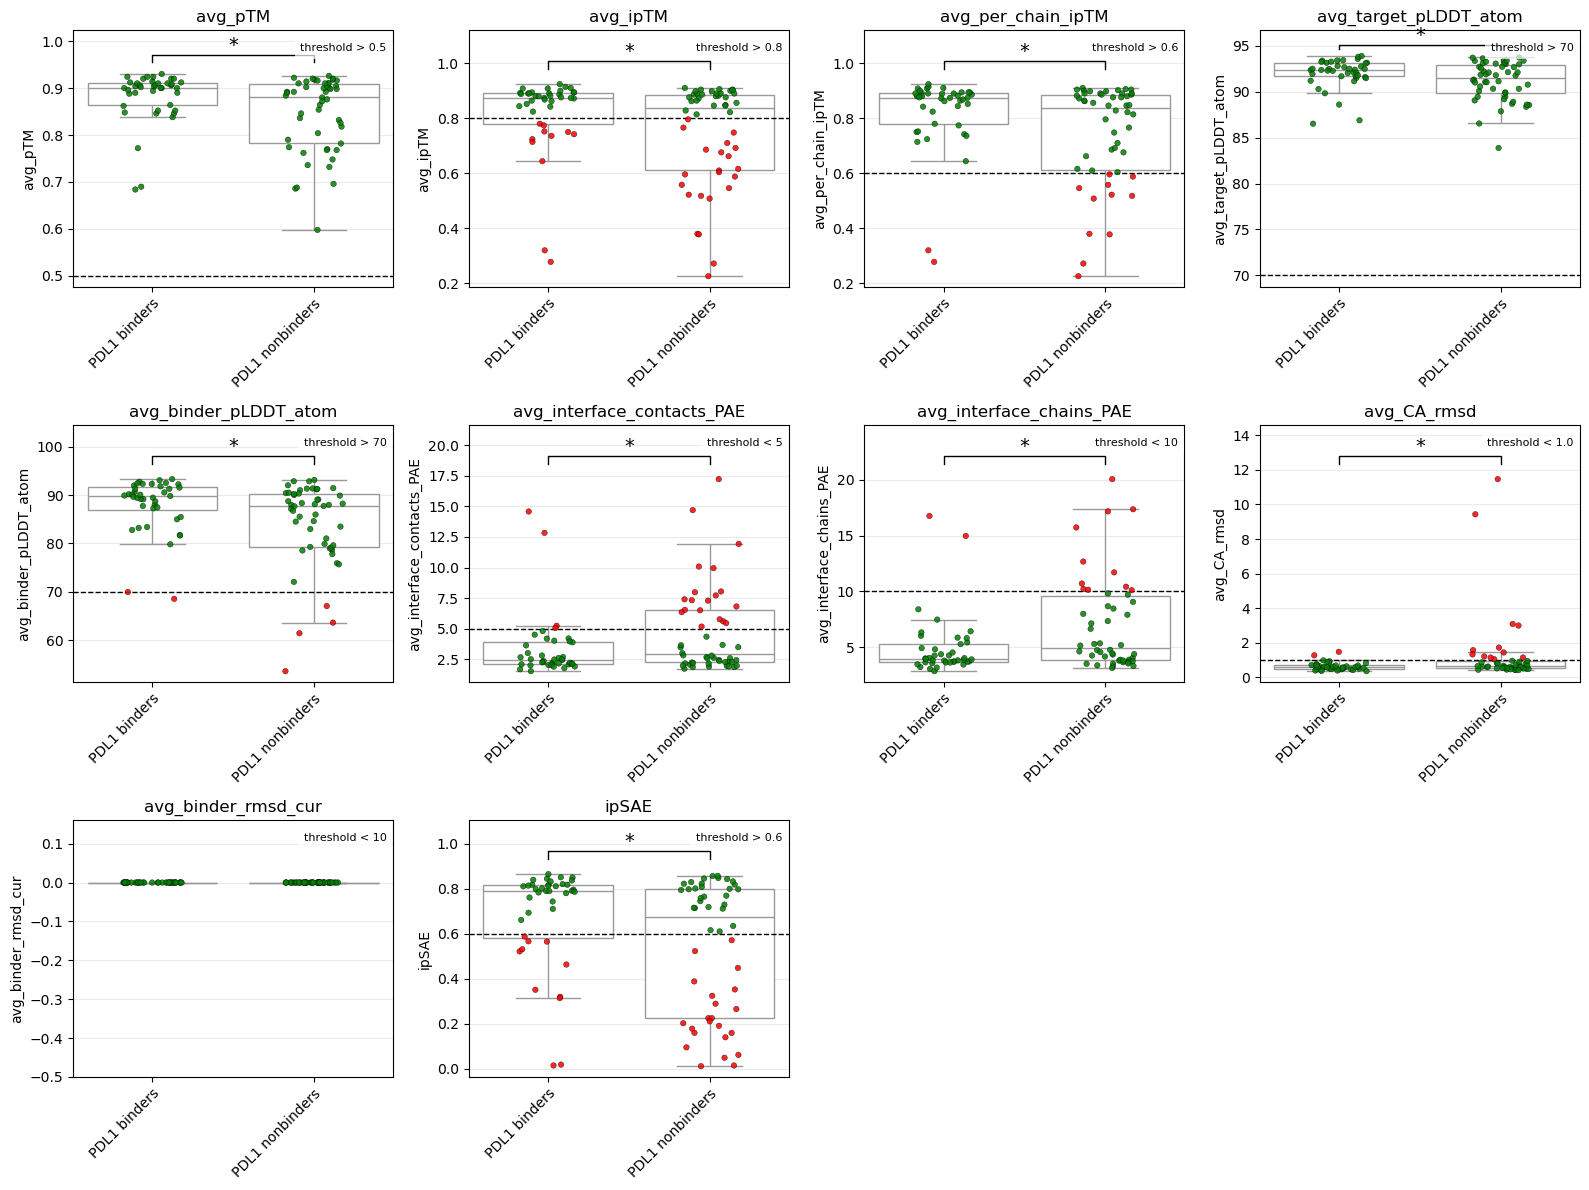

In [25]:
from IPython.display import Image, display

display(Image(filename="pdl1_results.png", width=800))
display(Image(filename="pdl1_results_2.png", width=800))

Since I don't have the the metrics for these PD-L1 binders (RIP scratch), let's make a relative score function

In [ ]:
def calculate_parrots_score(df):
	df = df.copy()

	score_metrics = {
		"avg_ipTM": "high",
		"avg_ipSAE": "high",
		"avg_interface_contacts_PAE": "low",
		"avg_CA_rmsd": "low",
		"hbond_energy/separated_interface": "high",
	}

	weights = {
		"avg_ipTM": 0.30,
		"avg_ipSAE": 0.30,
		"avg_interface_contacts_PAE": 0.15,
		"avg_CA_rmsd": 0.15,
		"hbond_energy/separated_interface": 0.10,
	}

	def minmax(s):
		s = pd.to_numeric(s, errors="coerce")
		if s.max() == s.min():
			return pd.Series(0.5, index=s.index)
		return (s - s.min()) / (s.max() - s.min())

	df["PARROTS_score"] = 0.0

	for metric, direction in score_metrics.items():
		if metric not in df.columns:
			print(f"Skipping missing metric: {metric}")
			continue

		norm = minmax(df[metric])

		if direction == "low":
			norm = 1 - norm

		df["PARROTS_score"] += weights[metric] * norm

	return df.sort_values("PARROTS_score", ascending=False)

#higher score is better

In [ ]:
df = pd.read_csv('/ifs/scratch2/home/bs3281/PARROTS_workshop/Test_2/ITER_1/AF3_Rosetta_df.csv')

scored_df = calculate_parrots_score(df)

scored_df[[
	"name",
	"PARROTS_score",
	"avg_ipTM",
	"avg_ipSAE",
	"avg_interface_contacts_PAE",
	"avg_CA_rmsd",
	"hbond_energy/separated_interface",
]].head(20)